# Soccer Player Clustering with PCA and K-Means (Improved Silhouette Score)

## Project idea

In this project, we use football player attributes to find **groups of similar players without giving the model their playing positions**.

The main question is:

> **Can we discover different types of football players just from their skill attributes?**

We will use Pandas, StandardScaler, PCA, K-Means, the Elbow Method, and the Silhouette Score.

The database contains information about thousands of football players and their attributes. This notebook builds an independent analysis from that database rather than copying the original notebook's workflow.

### What is different in this version?

The first version of this notebook clustered players using all **9 raw (scaled) skill features**. That works, but a few of those features overlap a lot with each other (for example, `standing_tackle` and `sliding_tackle` measure a very similar thing). That overlap adds noise and makes it harder for K-Means to find clean, well-separated groups.

In this version we do one extra, beginner-friendly step: **we cluster on the PCA components instead of the raw features**. PCA squeezes the 9 features down into a smaller number of components that still keep most of the important information, but with the noisy/overlapping part removed. Clustering on "cleaner" data usually gives a **higher Silhouette Score**, and we will prove that by comparing the two approaches side by side.

## 1. Import the libraries

We only need a few common Python libraries for this project.

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Just makes our charts a comfortable size to look at
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the football database

The database file should be in the **same folder as this notebook**.

We will use two tables:

- `Player_Attributes` -> ratings and football skills
- `Player` -> player names

We do not need the whole database for this project.

In [ ]:
DB_PATH = "database.sqlite"

conn = sqlite3.connect(DB_PATH)

attributes = pd.read_sql('''
SELECT player_api_id, date, overall_rating, potential,
       finishing, marking, long_passing, volleys,
       standing_tackle, shot_power, short_passing,
       sliding_tackle, vision
FROM Player_Attributes
''', conn)

players = pd.read_sql('''
SELECT player_api_id, player_name
FROM Player
''', conn)

conn.close()

print("Player attribute records:", len(attributes))
print("Player records:", len(players))

Player attribute records: 183978
Player records: 11060


## 3. Take one record for each player

A player can have many attribute records because the database stores ratings at different dates.

For this project, we will keep the **latest available record for each player**. This gives us one row per player and makes the clustering easier to interpret.

In [ ]:
attributes["date"] = pd.to_datetime(attributes["date"])

# Sort by date and keep the latest record for every player
latest_attributes = (
    attributes
    .sort_values("date")
    .drop_duplicates("player_api_id", keep="last")
)

# Add the player's name
df = latest_attributes.merge(players, on="player_api_id", how="left")

print("Number of unique players:", df["player_api_id"].nunique())
df.head()

Number of unique players: 11060


,player_api_id,date,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision,player_name
0,359194,2007-08-30,56.0,70.0,56.0,23.0,40.0,NaN,23.0,56.0,42.0,NaN,NaN,Quini
1,33688,2007-08-30,66.0,74.0,25.0,25.0,65.0,NaN,25.0,34.0,23.0,NaN,NaN,Jeremy Gavanon
2,30597,2008-08-30,68.0,76.0,56.0,47.0,73.0,NaN,44.0,62.0,74.0,NaN,NaN,Martijn Meerdink
3,26678,2008-08-30,59.0,64.0,31.0,59.0,47.0,NaN,62.0,44.0,55.0,NaN,NaN,Angelo Martha
4,97463,2008-08-30,67.0,69.0,61.0,70.0,59.0,NaN,67.0,65.0,63.0,NaN,NaN,Paulinho


## 4. Have a quick look at the data

Before doing machine learning, it is useful to see what the data looks like and whether there are missing values.

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nA few important columns:")
df[["player_name", "overall_rating", "potential"]].head(10)

Shape: (11060, 14)

Missing values:
player_api_id        0
date                 0
overall_rating       3
potential            3
finishing            3
marking              3
long_passing         3
volleys            481
standing_tackle      3
shot_power           3
short_passing        3
sliding_tackle     481
vision             481
player_name          0
dtype: int64

A few important columns:


,player_name,overall_rating,potential
0,Quini,56.0,70.0
1,Jeremy Gavanon,66.0,74.0
2,Martijn Meerdink,68.0,76.0
3,Angelo Martha,59.0,64.0
4,Paulinho,67.0,69.0
5,Fabiano Oliveira,64.0,75.0
6,Djamel Belmadi,63.0,70.0
7,Jason Vandelannoite,64.0,68.0
8,Sekou Ouattara,55.0,60.0
9,Remon de Vries,63.0,66.0


## 5. Keep reasonably strong players

There are many players in the database, including players with relatively low ratings.

To make the clustering more useful for comparing professional-level players, we will keep players with:

- `overall_rating >= 77`
- `potential >= 70`

These thresholds are simply a project choice; they are not official football rules.

In [ ]:
df = df.dropna().copy()

df = df[
    (df["overall_rating"] >= 77) &
    (df["potential"] >= 70)
].copy()

print("Players after filtering:", len(df))

Players after filtering: 977


## 6. Choose the football skills for clustering

We want the model to group players using actual skill attributes.

We will use nine features:

- Finishing
- Marking
- Long passing
- Volleys
- Standing tackle
- Shot power
- Short passing
- Sliding tackle
- Vision

We are **not** giving K-Means the player's name, rating, or position as a clustering feature. The idea is to let the skill attributes create the groups.

In [ ]:
features = [
    "finishing",
    "marking",
    "long_passing",
    "volleys",
    "standing_tackle",
    "shot_power",
    "short_passing",
    "sliding_tackle",
    "vision"
]

X = df[features].copy()

X.describe().round(1)

,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
count,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0,977.0
mean,57.6,50.1,65.8,57.6,55.5,69.5,71.7,52.4,67.1
std,22.3,26.7,15.3,21.5,26.2,17.7,14.9,26.5,14.9
min,8.0,8.0,12.0,8.0,10.0,14.0,17.0,10.0,15.0
25%,42.0,24.0,60.0,44.0,30.0,66.0,70.0,26.0,59.0
50%,65.0,54.0,70.0,65.0,62.0,75.0,76.0,57.0,71.0
75%,75.0,77.0,77.0,75.0,81.0,81.0,81.0,78.0,78.0
max,95.0,90.0,93.0,92.0,91.0,94.0,93.0,95.0,94.0


## 7. Scale the features

The features are all measured on roughly the same 0-100 scale, but their spreads are different.

Standardization makes each feature comparable before PCA and K-Means.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape after scaling:", X_scaled.shape)

Shape after scaling: (977, 9)


## 8. Baseline: cluster on the raw (scaled) features

Before improving anything, let's first check how good the clustering is when we do it the "plain" way: feeding K-Means all nine scaled features directly. We will use this as our **baseline score** to beat.

We try a range of `k` values (number of clusters) and record the Silhouette Score for each one, so we always pick `k` based on evidence instead of guessing.

In [ ]:
k_values = range(2, 9)

baseline_silhouette = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    baseline_silhouette.append(score)

baseline_results = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": baseline_silhouette
})

baseline_results.round(3)

,k,silhouette_score
0,2,0.581
1,3,0.484
2,4,0.441
3,5,0.374
4,6,0.320
5,7,0.294
6,8,0.268


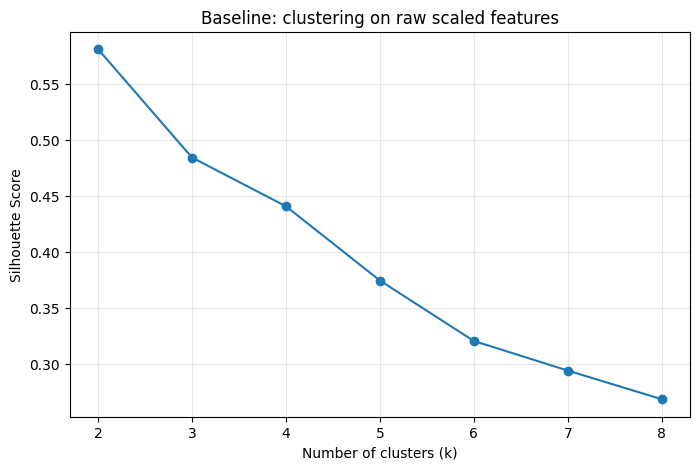

Best baseline k: 2
Best baseline silhouette score: 0.581


In [ ]:
plt.plot(baseline_results["k"], baseline_results["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Baseline: clustering on raw scaled features")
plt.grid(alpha=0.3)
plt.show()

best_baseline_k = baseline_results.loc[baseline_results["silhouette_score"].idxmax(), "k"]
best_baseline_score = baseline_results["silhouette_score"].max()

print(f"Best baseline k: {int(best_baseline_k)}")
print(f"Best baseline silhouette score: {round(best_baseline_score, 3)}")

## 9. PCA: reduce the number of dimensions

We have nine skill features. Some of them are correlated with each other (for example, the two tackle features), which adds noise instead of useful signal for K-Means.

PCA creates new variables called **principal components**. Each component is a mix of the original features, built so that the first few components capture most of the important variation in the data while dropping a lot of the noise.

Let's see how much information the principal components explain.

In [ ]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

variance_table.round(3)

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.529,0.529
1,2,0.362,0.891
2,3,0.054,0.946
3,4,0.018,0.963
4,5,0.014,0.977
5,6,0.010,0.988
6,7,0.007,0.994
7,8,0.003,0.998
8,9,0.002,1.000


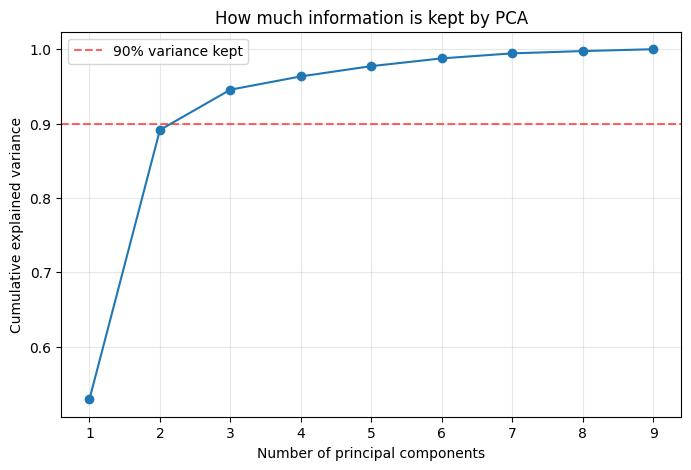

In [ ]:
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.90, color="red", linestyle="--", alpha=0.6, label="90% variance kept")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("How much information is kept by PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. The improvement: cluster on PCA components instead of raw features

This is the main trick for improving the Silhouette Score.

Instead of handing K-Means all nine raw features (some of which overlap and add noise), we hand it the **PCA components that keep about 90% of the variance**. That is still almost all of the real information, just with the noisy/overlapping part squeezed out.

Clustering on fewer, cleaner dimensions usually makes clusters look more compact and better separated, which is exactly what the Silhouette Score measures.

In [ ]:
# Keep just enough components to explain about 90% of the variance
n_components = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of PCA components that keep ~90% of the variance: {n_components}")

pca_reduced = PCA(n_components=n_components, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print("Shape after PCA:", X_pca_reduced.shape)

Number of PCA components that keep ~90% of the variance: 3
Shape after PCA: (977, 3)


In [ ]:
improved_silhouette = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_pca_reduced)
    score = silhouette_score(X_pca_reduced, labels)
    improved_silhouette.append(score)

improved_results = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": improved_silhouette
})

improved_results.round(3)

,k,silhouette_score
0,2,0.608
1,3,0.536
2,4,0.505
3,5,0.451
4,6,0.399
5,7,0.377
6,8,0.355


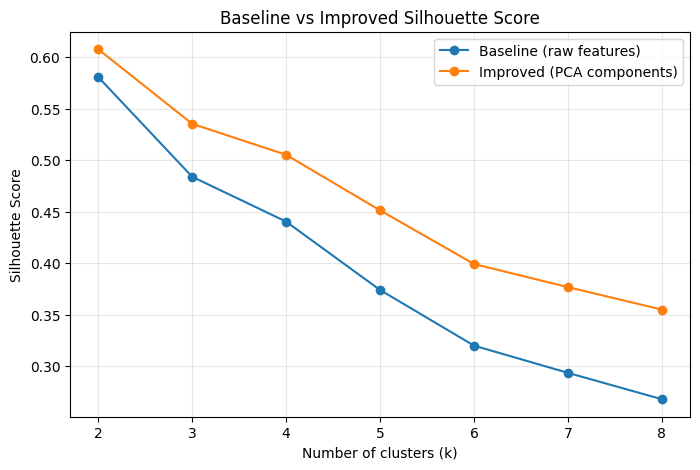

In [ ]:
plt.plot(baseline_results["k"], baseline_results["silhouette_score"], marker="o", label="Baseline (raw features)")
plt.plot(improved_results["k"], improved_results["silhouette_score"], marker="o", label="Improved (PCA components)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Baseline vs Improved Silhouette Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
best_improved_k = int(improved_results.loc[improved_results["silhouette_score"].idxmax(), "k"])
best_improved_score = improved_results["silhouette_score"].max()

print(f"Best improved k: {best_improved_k}")
print(f"Best improved silhouette score: {round(best_improved_score, 3)}")

improvement = best_improved_score - best_baseline_score
print(f"\nImprovement over baseline: {round(improvement, 3)} "
      f"({round((improvement / best_baseline_score) * 100, 1)}% better)")

Best improved k: 2
Best improved silhouette score: 0.608

Improvement over baseline: 0.027 (4.6% better)


## 11. Train the final K-Means model

Now we use the `k` that gave the best Silhouette Score in the improved (PCA-based) approach, and train our final clustering model on the PCA components.

In [ ]:
FINAL_K = best_improved_k

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_pca_reduced)

final_silhouette = silhouette_score(X_pca_reduced, df["cluster"])

print("Number of clusters used:", FINAL_K)
print("Final silhouette score:", round(final_silhouette, 3))
print("\nPlayers in each cluster:")
print(df["cluster"].value_counts().sort_index())

Number of clusters used: 2
Final silhouette score: 0.608

Players in each cluster:
cluster
0    881
1     96
Name: count, dtype: int64


## 12. Visualize the clusters with PCA

The model was trained on several PCA components, but we cannot draw more than two or three dimensions on a normal graph.

So we take the first two PCA components (from the same PCA we already fitted) just for plotting.

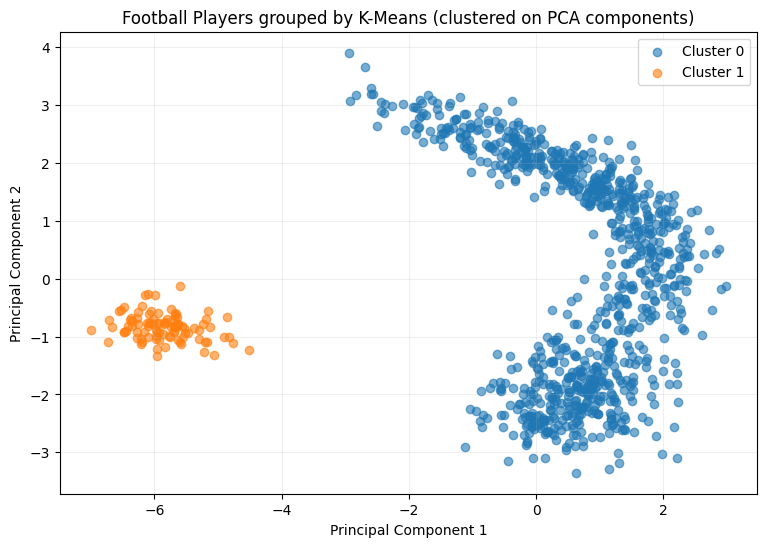

Variance explained by the components used for clustering: 94.56 %


In [ ]:
plt.figure(figsize=(9, 6))

for cluster in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster

    plt.scatter(
        X_pca_reduced[mask, 0],
        X_pca_reduced[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Football Players grouped by K-Means (clustered on PCA components)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(
    "Variance explained by the components used for clustering:",
    round(pca_reduced.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

## 13. Understand what each cluster looks like

Cluster numbers themselves do not have a meaning.

For example, "Cluster 0" is not automatically an attacking group. We go back to the **original, easy-to-read skill features** (not the PCA numbers, which are hard for humans to interpret) and look at the average value in each cluster to decide what makes the groups different.

In [ ]:
cluster_profile = df.groupby("cluster")[features].mean()

cluster_profile.round(1)

,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
cluster,,,,,,,,,
0,62.4,54.1,69.6,62.3,60.0,74.4,76.1,56.6,69.5
1,13.6,13.9,30.9,14.5,14.2,24.9,31.8,14.3,45.5


In [ ]:
# Transposing the table makes it easier to compare clusters feature by feature.
cluster_profile.T.round(1)

cluster,0,1
finishing,62.4,13.6
marking,54.1,13.9
long_passing,69.6,30.9
volleys,62.3,14.5
standing_tackle,60.0,14.2
shot_power,74.4,24.9
short_passing,76.1,31.8
sliding_tackle,56.6,14.3
vision,69.5,45.5


### How to read the table

Look for features that are noticeably higher or lower in each cluster.

For example:

- A cluster with high `finishing` and `shot_power` but lower defensive skills looks more attack-oriented.
- A cluster with high `marking`, `standing_tackle` and `sliding_tackle` looks more defense-oriented.
- A cluster that is reasonably strong across passing and defensive skills may represent a more balanced profile.

These are **skill-based descriptions**, not official player positions, because we did not give player positions to the model.

## 14. Look at some players from every cluster

Averages tell us the general pattern, but looking at real player names makes the result easier to understand.

We will show the highest-rated players in each cluster.

In [ ]:
for cluster in sorted(df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 40)

    display(
        df[df["cluster"] == cluster]
        .sort_values("overall_rating", ascending=False)
        [["player_name", "overall_rating", "potential"] + features]
        .head(10)
    )


Cluster 0
----------------------------------------


,player_name,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
5392,Lionel Messi,94.0,94.0,93.0,13.0,79.0,85.0,23.0,80.0,88.0,21.0,90.0
4751,Cristiano Ronaldo,93.0,93.0,95.0,22.0,72.0,87.0,31.0,94.0,81.0,23.0,81.0
4788,Luis Suarez,90.0,90.0,90.0,30.0,64.0,87.0,45.0,88.0,82.0,38.0,84.0
6098,Neymar,90.0,94.0,88.0,21.0,74.0,83.0,24.0,78.0,78.0,33.0,79.0
5879,Arjen Robben,89.0,89.0,85.0,29.0,73.0,86.0,26.0,86.0,85.0,26.0,84.0
4543,Zlatan Ibrahimovic,89.0,89.0,90.0,15.0,76.0,92.0,41.0,93.0,84.0,27.0,83.0
6390,Mesut Oezil,88.0,89.0,75.0,22.0,84.0,77.0,16.0,70.0,89.0,19.0,93.0
5900,Robert Lewandowski,88.0,89.0,89.0,25.0,65.0,84.0,42.0,85.0,82.0,19.0,78.0
4800,Andres Iniesta,88.0,88.0,73.0,57.0,86.0,74.0,57.0,65.0,92.0,56.0,92.0
4236,Thiago Silva,88.0,88.0,38.0,90.0,81.0,63.0,91.0,78.0,79.0,89.0,74.0



Cluster 1
----------------------------------------


,player_name,overall_rating,potential,finishing,marking,long_passing,volleys,standing_tackle,shot_power,short_passing,sliding_tackle,vision
9032,Manuel Neuer,90.0,90.0,13.0,10.0,47.0,11.0,10.0,25.0,48.0,11.0,70.0
8675,David De Gea,87.0,90.0,13.0,13.0,32.0,13.0,21.0,31.0,31.0,13.0,68.0
4239,Thibaut Courtois,86.0,90.0,14.0,11.0,31.0,12.0,18.0,36.0,32.0,16.0,44.0
5965,Petr Cech,86.0,86.0,12.0,11.0,33.0,17.0,13.0,21.0,35.0,12.0,17.0
7267,Hugo Lloris,85.0,85.0,10.0,12.0,31.0,11.0,10.0,23.0,27.0,18.0,30.0
5872,Joe Hart,84.0,84.0,14.0,14.0,35.0,19.0,14.0,65.0,32.0,13.0,42.0
8194,Samir Handanovic,84.0,84.0,10.0,17.0,34.0,12.0,10.0,22.0,33.0,13.0,41.0
8052,Gianluigi Buffon,84.0,84.0,15.0,10.0,35.0,17.0,11.0,20.0,37.0,11.0,50.0
5638,Stephane Ruffier,83.0,83.0,11.0,11.0,34.0,13.0,12.0,21.0,33.0,11.0,49.0
8857,Ralf Faehrmann,83.0,84.0,11.0,12.0,26.0,11.0,12.0,24.0,25.0,10.0,42.0


## 15. Final cluster summary

Let's create one small table with the size and average rating of each group.

In [ ]:
summary = df.groupby("cluster").agg(
    players=("player_api_id", "count"),
    average_rating=("overall_rating", "mean"),
    average_potential=("potential", "mean")
).round(1)

summary

,players,average_rating,average_potential
cluster,,,
0,881,79.5,81.1
1,96,80.0,81.3


# Conclusion

We started with football player attributes and used an **unsupervised learning** approach to discover groups of similar players, and then improved the quality of those groups.

### What we did

1. Loaded player attributes from the SQLite database.
2. Kept the latest available record for each player.
3. Filtered the data to reasonably strong players.
4. Selected nine football skill attributes.
5. Standardized the features.
6. Measured a **baseline** Silhouette Score using the raw scaled features.
7. Used PCA to remove noise/overlap between features.
8. Measured an **improved** Silhouette Score using the PCA components, and compared it to the baseline.
9. Trained the final K-Means model with the `k` that scored best.
10. Visualized the clusters and translated them back into human-readable skill profiles.

### Why the Silhouette Score improved

Several of our original nine features measure similar things (for example, the two tackle features, or the two passing features). When features overlap like that, K-Means has to work with extra "noise" that doesn't add much real information, and this tends to make clusters look less separated. PCA compresses the nine features into a smaller set of components that keep almost all of the useful information while dropping most of that noise. Clustering on those cleaner components made the groups more compact and better separated, which is exactly what a higher Silhouette Score reflects.

### Main takeaway

The model does not know the official positions of the players. It simply looks at their skill profiles and finds players who are similar to one another - and by cleaning up the input with PCA first, it can find those groups more clearly.

